<a href="https://colab.research.google.com/github/AhalaAyyalas/MachineLearning/blob/main/ML_Assign18NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1

In [2]:
#@title Tokenisation


from sklearn.feature_extraction.text import CountVectorizer

text = ["""The Indian Premier League (IPL) is the world's most popular Twenty20 cricket tournament,
         featuring city-based franchise teams competing annually in India. The Indian Premier League
         (IPL) is the world's most popular Twenty20 cricket tournament, featuring city-based franchise
         teams competing annually in India. Founded by the BCCI in 2008, it revolutionized cricket by
         blending sport with entertainment, attracting global superstars and billions of viewers.
        Today, it stands as one of the richest sporting leagues in the world."""]
vectorizer = CountVectorizer()
vectorizer.fit(text)
print("Tokens:", vectorizer.get_feature_names_out())


Tokens: ['2008' 'and' 'annually' 'as' 'attracting' 'based' 'bcci' 'billions'
 'blending' 'by' 'city' 'competing' 'cricket' 'entertainment' 'featuring'
 'founded' 'franchise' 'global' 'in' 'india' 'indian' 'ipl' 'is' 'it'
 'league' 'leagues' 'most' 'of' 'one' 'popular' 'premier' 'revolutionized'
 'richest' 'sport' 'sporting' 'stands' 'superstars' 'teams' 'the' 'today'
 'tournament' 'twenty20' 'viewers' 'with' 'world']


In [3]:
#@title Stopword Removal

from sklearn.feature_extraction.text import CountVectorizer

text = ["""The Indian Premier League (IPL) is the world's most popular Twenty20 cricket tournament,
           featuring city-based franchise teams competing annually in India. The Indian Premier League
           (IPL) is the world's most popular Twenty20 cricket tournament, featuring city-based franchise
           teams competing annually in India. Founded by the BCCI in 2008, it revolutionized cricket by
           blending sport with entertainment, attracting global superstars and billions of viewers.
           Today, it stands as one of the richest sporting leagues in the world."""]

# Without stopword removal
vec1 = CountVectorizer()
vec1.fit(text)
print("All words:", vec1.get_feature_names_out())

# With stopword removal
vec2 = CountVectorizer(stop_words='english')
vec2.fit(text)
print("\nAfter removing stopwords:", vec2.get_feature_names_out())

print("Stopwords dont really have a significant meaning by themselves and the overall meaning of the sentence remains more or less the same even if they are removed.")

All words: ['2008' 'and' 'annually' 'as' 'attracting' 'based' 'bcci' 'billions'
 'blending' 'by' 'city' 'competing' 'cricket' 'entertainment' 'featuring'
 'founded' 'franchise' 'global' 'in' 'india' 'indian' 'ipl' 'is' 'it'
 'league' 'leagues' 'most' 'of' 'one' 'popular' 'premier' 'revolutionized'
 'richest' 'sport' 'sporting' 'stands' 'superstars' 'teams' 'the' 'today'
 'tournament' 'twenty20' 'viewers' 'with' 'world']

After removing stopwords: ['2008' 'annually' 'attracting' 'based' 'bcci' 'billions' 'blending'
 'city' 'competing' 'cricket' 'entertainment' 'featuring' 'founded'
 'franchise' 'global' 'india' 'indian' 'ipl' 'league' 'leagues' 'popular'
 'premier' 'revolutionized' 'richest' 'sport' 'sporting' 'stands'
 'superstars' 'teams' 'today' 'tournament' 'twenty20' 'viewers' 'world']
Stopwords dont really have a significant meaning by themselves and the overall meaning of the sentence remains more or less the same even if they are removed.


### If you were building a spam detector for emails, which of these would be more useful — keeping stopwords or removing them? Explain your reasoning in 2–3 sentences.

-- Removing stopwords would be more useful as they would just take up more space and more visual information without adding much to the meaning. By removing them, the model can focus on more important words that truly signify whether an email is spam or not. This helps in reducing noise and improving the efficiency and accuracy of the spam detection model.

# Part 2

In [11]:
#@title TF-IDF + Logistic Regression sentiment classifier on the IMDB dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tensorflow import keras
import numpy as np
import time

# Step 1: Load IMDB dataset
print("Loading IMDB dataset...")
(x_train_idx, y_train), (x_test_idx, y_test) = keras.datasets.imdb.load_data(num_words=10000)

# Convert integer sequences back to text
word_index = keras.datasets.imdb.get_word_index()
reverse_index = {v + 3: k for k, v in word_index.items()}
reverse_index[0] = ''    # padding
reverse_index[1] = ''    # start token
reverse_index[2] = ''    # unknown

def decode_review(encoded):
    return ' '.join([reverse_index.get(i, '?') for i in encoded])

# Decode all reviews back to text
print("Decoding reviews to text...")
train_texts = [decode_review(r) for r in x_train_idx]
test_texts = [decode_review(r) for r in x_test_idx]

print(f"  Training reviews: {len(train_texts)}")
print(f"  Test reviews: {len(test_texts)}")
print(f"\nSample review (first 200 chars):")
print(f'  "{train_texts[0][:200]}..."')
print(f"  Label: {'Positive' if y_train[0] == 1 else 'Negative'}")

# Step 2: TF-IDF feature extraction
print("\nExtracting TF-IDF features...")
tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
X_train = tfidf.fit_transform(train_texts)
X_test = tfidf.transform(test_texts)
print(f"  Feature matrix shape: {X_train.shape}")

# Step 3: Train Logistic Regression
print("\nTraining Logistic Regression...")
start = time.time()
model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train, y_train)
train_time = time.time() - start

# Step 4: Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'=' * 50}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Training Time: {train_time:.1f} seconds")
print(f"{'=' * 50}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Loading IMDB dataset...
Decoding reviews to text...
  Training reviews: 25000
  Test reviews: 25000

Sample review (first 200 chars):
  " this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert  is an amazing actor and now the same..."
  Label: Positive

Extracting TF-IDF features...
  Feature matrix shape: (25000, 9477)

Training Logistic Regression...

Test Accuracy: 88.12%
Training Time: 0.5 seconds

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



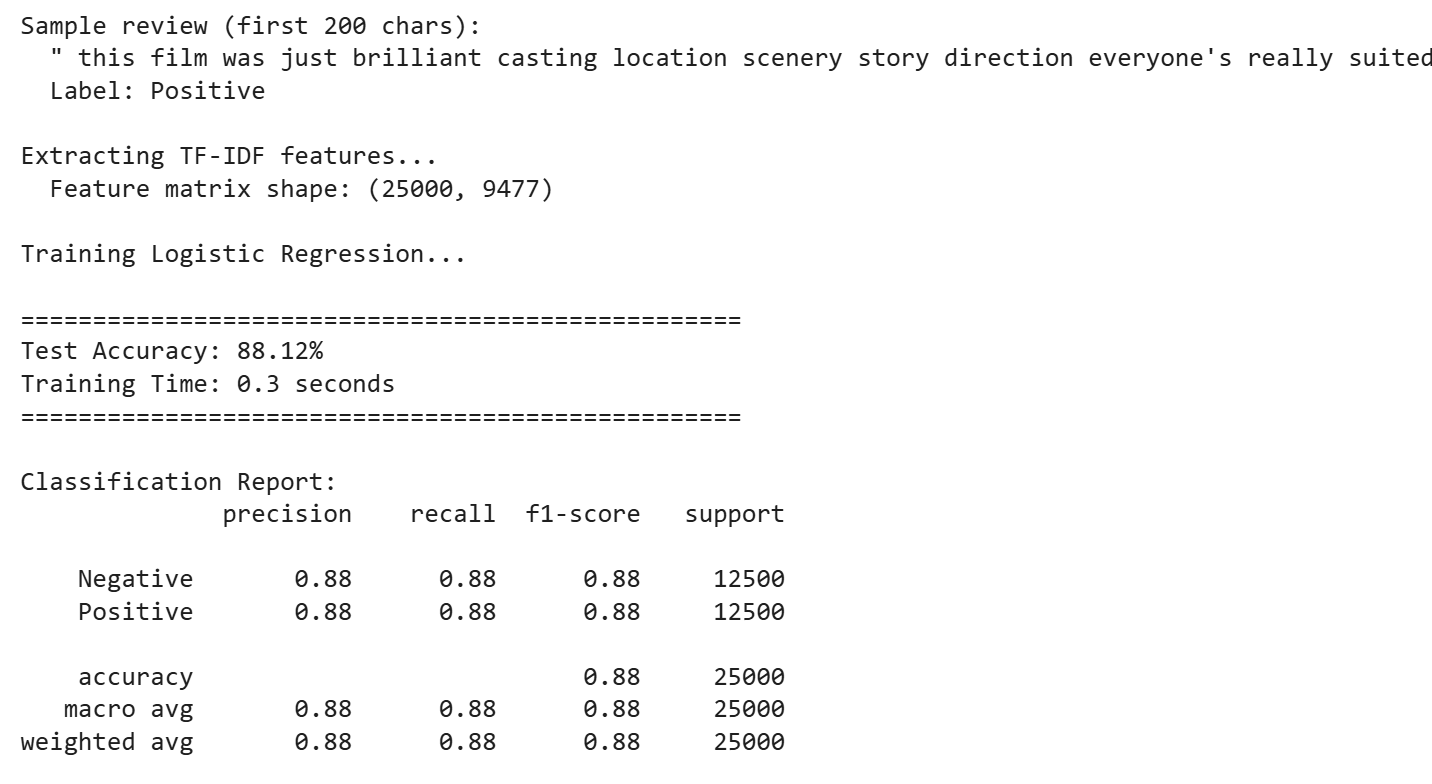

In [18]:
#@title With 3 of my own sentences

my_reviews = [
    'The plot was great but the acting was very mid.',
    'It was a wonderful film with outstanding performances from the cast.',
    'That was a terrible movie with no story or any solid acting.'
]

print("Testing your own reviews:\n")
X_new = tfidf.transform(my_reviews)
predictions = model.predict(X_new)
probabilities = model.predict_proba(X_new)

for review, pred, probs in zip(my_reviews, predictions, probabilities):
    sentiment = "POSITIVE" if pred == 1 else "NEGATIVE"
    confidence = max(probs) * 100
    print(f'  "{review}"')
    print(f'  --> {sentiment} ({confidence:.1f}% confident)')
    print()

Testing your own reviews:

  "The plot was great but the acting was very mid."
  --> POSITIVE (69.1% confident)

  "It was a wonderful film with outstanding performances from the cast."
  --> POSITIVE (99.1% confident)

  "That was a terrible movie with no story or any solid acting."
  --> NEGATIVE (78.9% confident)



### 1) Did the model correctly predict the sentiment of your 3 reviews? If not, which one did it get wrong and why do you think it struggled?

-- Yes the model correctly predicted my sentiments behind the 3 reviews.

### 2) Look at the TF-IDF feature names — what are the top 5 most important words for positive reviews and the top 5 for negative reviews?

-- Top 5 most important words for good reviews: Great, Excellent, Best, Perfect, Wonderful
-- Top 5 most important words for bad reviews: Worst, Bad, Waste, Awful, Boring

### 3) In 2–3 sentences, explain how TF-IDF helps the model distinguish between positive and negative reviews.

-- TF-IDF helps by assigning higher weightage to words that appear frequently in one review, but not across all reviews. However, commonly used words are not given as much importance.



# Part 3

### 1) Name 3 real-world applications of NLP that you personally use or encounter in your daily life. For each one, briefly explain what NLP task it performs (e.g., classification, translation, text generation).

-- Email Spam filtering (classification), Search Engines (information retrieval), Autocorrect (text generation)

### 2) Compare the scikit-learn approach and the Keras approach from this lesson. Which one was easier to understand? Which one do you think would work better on a much harder task (like translating English to Spanish)? Why?

-- Personally I think the scikit-learn approach was better as it was a more straightofrward approach. However, for more complex tasks I think Keras would be better as it is specifically designed to handle sequential data.

### 3) Think back to the classic ML algorithms we learned in Weeks 1–22 (KNN, Decision Trees, SVM, etc.). How is NLP different from those earlier projects? What's the extra step that NLP requires before you can use any ML algorithm?

-- ML algorithms (KNN, Decision Trees, etc) typically function on structured numerical data while NLP deals with text data. It also has an extra step that is text preprocessing before using any ML algorithm.